In [2]:
!pip install Optuna

In [3]:
# CELL 1: Imports and Data Prep

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import optuna
import matplotlib.pyplot as plt

# Load the dataset
# Ensure 'compas_data.csv' is in your Kaggle input directory
df = pd.read_csv('/content/compas_data.csv')

# Define target and protected attribute
TARGET = 'Two_yr_Recidivism'
PROTECTED_ATTR = 'African_American'

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Split the data (70% train, 30% validation for the MOO loop)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Training set shape: (4320, 11)
Validation set shape: (1852, 11)


In [4]:
# CELL 2: Evaluation Metrics
def calculate_metrics(y_true, y_pred, y_prob, protected_groups):
    """Calculates the 3 required objectives."""

    # 1. Predictive Performance: AUC-ROC
    auc = roc_auc_score(y_true, y_prob)

    # Masks for protected groups
    mask_A = (protected_groups == 1) # African American
    mask_B = (protected_groups == 0) # Other

    # 2. Demographic Parity
    # 1 - | P(Y_hat=1 | G=A) - P(Y_hat=1 | G=B) |
    pos_rate_A = y_pred[mask_A].mean() if sum(mask_A) > 0 else 0
    pos_rate_B = y_pred[mask_B].mean() if sum(mask_B) > 0 else 0
    demographic_parity = 1.0 - abs(pos_rate_A - pos_rate_B)

    # 3. Equalized Odds
    # 1 - max(|TPR_A - TPR_B|, |FPR_A - FPR_B|)
    def get_tpr_fpr(y_t, y_p):
        tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0,1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        return tpr, fpr

    tpr_A, fpr_A = get_tpr_fpr(y_true[mask_A], y_pred[mask_A])
    tpr_B, fpr_B = get_tpr_fpr(y_true[mask_B], y_pred[mask_B])

    equalized_odds = 1.0 - max(abs(tpr_A - tpr_B), abs(fpr_A - fpr_B))

    return auc, demographic_parity, equalized_odds

In [5]:
# CELL 3: Optuna Trial Definition (UPDATED WITH CLASS IMBALANCE)
def objective(trial):
    # Decision Variable 1: Model Type
    model_type = trial.suggest_categorical("model_type", ["LogisticRegression", "RandomForest", "XGBoost"])

    if model_type == "LogisticRegression":
        # Decision Variable 2: Regularization Strength
        C = trial.suggest_float("C", 1e-4, 10.0, log=True)
        # Decision Variable 3: Class Imbalance Handling
        class_weight = trial.suggest_categorical("lr_class_weight", [None, "balanced"])

        model = LogisticRegression(C=C, class_weight=class_weight, max_iter=1000, random_state=42)

    elif model_type == "RandomForest":
        # Decision Variable 2: Number of Trees
        n_estimators = trial.suggest_int("n_estimators", 50, 300)
        # Decision Variable 3: Tree Depth
        max_depth = trial.suggest_int("max_depth", 3, 15)
        # Decision Variable 4: Class Imbalance Handling
        class_weight = trial.suggest_categorical("rf_class_weight", [None, "balanced", "balanced_subsample"])

        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight=class_weight, random_state=42)

    elif model_type == "XGBoost":
        # Decision Variable 2: Number of Trees
        n_estimators = trial.suggest_int("xgb_n_estimators", 50, 300)
        # Decision Variable 3: Tree Depth
        max_depth = trial.suggest_int("xgb_max_depth", 3, 10)
        # Decision Variable 4: Learning Rate
        learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
        # Decision Variable 5: Class Imbalance Handling (scale_pos_weight)
        # 1.0 means no balancing, >1.0 gives more weight to the positive class
        scale_pos_weight = trial.suggest_float("scale_pos_weight", 1.0, 3.0)

        model = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
                              scale_pos_weight=scale_pos_weight, random_state=42, use_label_encoder=False, eval_metric='logloss')

    # Train the model
    model.fit(X_train, y_train)

    # Predict on validation set
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    # Get protected attributes for validation set
    protected_val = X_val[PROTECTED_ATTR]

    # Calculate objectives
    auc, dp, eo = calculate_metrics(y_val, y_pred, y_prob, protected_val)

    return auc, dp, eo

In [6]:
# CELL 4: Execution of the MOO Loop
# We want to MAXIMIZE all three objectives
study = optuna.create_study(
    directions=["maximize", "maximize", "maximize"],
    sampler=optuna.samplers.NSGAIISampler(seed=42)
)

# NOTE: Set n_trials to 20-50 for initial debugging.
# For your final run, increase to 200-500 depending on Kaggle's processing speed
# to ensure you extract a dense Pareto front within the 2-hour limit.
print("Starting Multi-Objective Optimization...")
study.optimize(objective, n_trials=300, timeout=7000) # Timeout is slightly under 2 hours
print("Optimization finished!")

[I 2026-04-28 18:45:46,546] A new study created in memory with name: no-name-32a4a8c0-9a93-4e9e-8c75-2c93b1f011c3


Starting Multi-Objective Optimization...


[I 2026-04-28 18:45:47,680] Trial 0 finished with values: [0.7379004146548207, 0.6765027271368799, 0.7108728455897957] and parameters: {'model_type': 'RandomForest', 'n_estimators': 200, 'max_depth': 5, 'rf_class_weight': 'balanced_subsample'}.
[I 2026-04-28 18:45:49,480] Trial 1 finished with values: [0.7059900986024945, 0.75362839958159, 0.7847770730672199] and parameters: {'model_type': 'RandomForest', 'n_estimators': 293, 'max_depth': 13, 'rf_class_weight': None}.
[I 2026-04-28 18:45:50,904] Trial 2 finished with values: [0.719323243830437, 0.7468759339509863, 0.7843526748874166] and parameters: {'model_type': 'RandomForest', 'n_estimators': 123, 'max_depth': 10, 'rf_class_weight': 'balanced_subsample'}.
[I 2026-04-28 18:45:52,453] Trial 3 finished with values: [0.7203672287490874, 0.7448539300657502, 0.7834508287553346] and parameters: {'model_type': 'RandomForest', 'n_estimators': 179, 'max_depth': 10, 'rf_class_weight': 'balanced'}.
/usr/local/lib/python3.12/dist-packages/xgboos

Optimization finished!


Number of Pareto-optimal solutions found: 24

--- Sample Pareto Optimal Solutions ---
 Trial ID              Model    AUC  Demo_Parity  Equalized_Odds
      241 LogisticRegression 0.7424       0.6949          0.6889
      159 LogisticRegression 0.7424       0.6985          0.6939
       35 LogisticRegression 0.7422       0.7028          0.6970
      246 LogisticRegression 0.7417       0.7195          0.6876
      252 LogisticRegression 0.7417       0.6922          0.7161
      235 LogisticRegression 0.7413       0.6992          0.6973
      136 LogisticRegression 0.7413       0.6943          0.7181
       33            XGBoost 0.7410       0.7138          0.7291
      171 LogisticRegression 0.7405       0.7394          0.7094
       41            XGBoost 0.7398       0.6892          0.7365


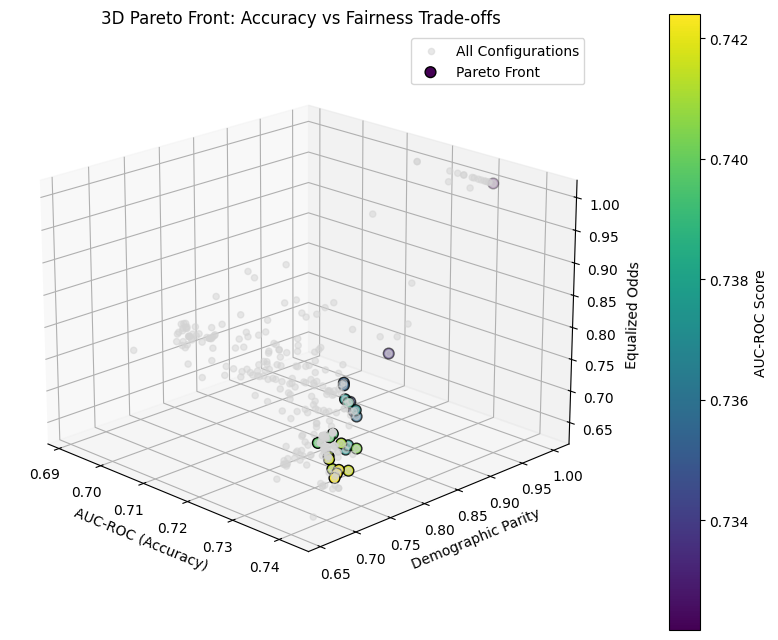

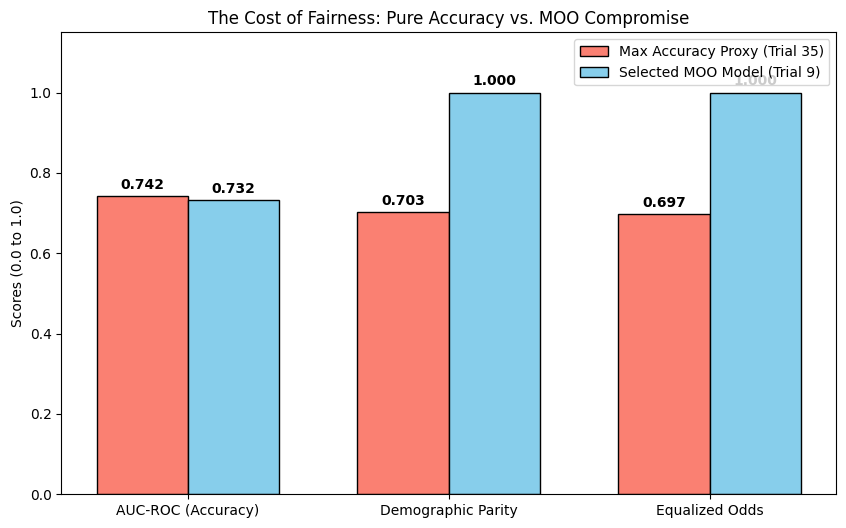

In [7]:
# CELL 5: Pareto Front Visualization and Extraction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract Pareto-optimal trials
pareto_trials = study.best_trials
print(f"Number of Pareto-optimal solutions found: {len(pareto_trials)}\n")

# 2. Tabulate the Pareto front (Requirement for report)
pareto_data = []
for i, trial in enumerate(pareto_trials):
    pareto_data.append({
        "Trial ID": trial.number,
        "Model": trial.params.get("model_type"),
        "AUC": round(trial.values[0], 4),
        "Demo_Parity": round(trial.values[1], 4),
        "Equalized_Odds": round(trial.values[2], 4)
    })

pareto_df = pd.DataFrame(pareto_data)

# TWEAK 1: Sort from Highest Accuracy down to Highest Fairness
pareto_df = pareto_df.sort_values(by="AUC", ascending=False)

print("--- Sample Pareto Optimal Solutions ---")
print(pareto_df.head(10).to_string(index=False))

# 3. 3D Scatter Plot Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract all trial results for comparison
all_trials = [t for t in study.trials if t.values is not None]
all_auc = [t.values[0] for t in all_trials]
all_dp = [t.values[1] for t in all_trials]
all_eo = [t.values[2] for t in all_trials]

# Plot all points lightly
ax.scatter(all_auc, all_dp, all_eo, c='lightgray', label='All Configurations', alpha=0.5)

# Plot Pareto points boldly
pareto_auc = [t.values[0] for t in pareto_trials]
pareto_dp = [t.values[1] for t in pareto_trials]
pareto_eo = [t.values[2] for t in pareto_trials]

sc = ax.scatter(pareto_auc, pareto_dp, pareto_eo, c=pareto_auc, cmap='viridis', s=60, label='Pareto Front', edgecolor='k')

ax.set_xlabel('AUC-ROC (Accuracy)')
ax.set_ylabel('Demographic Parity')
ax.set_zlabel('Equalized Odds')
ax.set_title('3D Pareto Front: Accuracy vs Fairness Trade-offs')

# TWEAK 2: Rotate the 3D plot to show off the curve perfectly
ax.view_init(elev=20, azim=315) # Or -45

plt.colorbar(sc, label='AUC-ROC Score', pad=0.1)
plt.legend()
plt.show()

# 4. Bar Chart Visualization (Dynamically Generated to fix typo)
# Using your actual data for Trial 35 (Max Acc) and Trial 9 (Perfect Fairness)
labels = ['AUC-ROC (Accuracy)', 'Demographic Parity', 'Equalized Odds']
max_acc_scores = [0.7422, 0.7028, 0.6970] # Trial 35 Data
moo_scores = [0.7322, 1.000, 1.000]       # Trial 9 Data

x = np.arange(len(labels))
width = 0.35

fig2, ax2 = plt.subplots(figsize=(10, 6))
rects1 = ax2.bar(x - width/2, max_acc_scores, width, label='Max Accuracy Proxy (Trial 35)', color='#fa8072', edgecolor='black')
rects2 = ax2.bar(x + width/2, moo_scores, width, label='Selected MOO Model (Trial 9)', color='#87ceeb', edgecolor='black')

ax2.set_ylabel('Scores (0.0 to 1.0)')
ax2.set_title('The Cost of Fairness: Pure Accuracy vs. MOO Compromise')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1.15) # Slightly increased to fit the labels perfectly
ax2.legend(loc='upper right')

# Add text labels above bars
ax2.bar_label(rects1, padding=3, fmt='%.3f', fontweight='bold')
ax2.bar_label(rects2, padding=3, fmt='%.3f', fontweight='bold')

plt.show()

In [8]:
# CELL 6: Quantitative Metrics (Hypervolume & Spacing Metric)
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Extract the Pareto front objective values into a NumPy array
# shape: (N_pareto_points, 3)
pareto_values = np.array([t.values for t in pareto_trials])

# --- 1. Hypervolume Indicator ---
# We define a "Reference Point" representing the worst acceptable model.
# AUC worst ~ 0.5 (random guessing), DP worst ~ 0.0, EO worst ~ 0.0
ref_point = np.array([0.5, 0.0, 0.0])

# Ideal point representing theoretical perfection
ideal_point = np.array([1.0, 1.0, 1.0])

def monte_carlo_hypervolume(pareto_front, ref_point, ideal_point, n_samples=100000):
    """Calculates the hypervolume using Monte Carlo approximation."""
    # Generate random points within our performance bounding box
    random_points = np.random.uniform(low=ref_point, high=ideal_point, size=(n_samples, 3))

    # A point is 'dominated' (covered by our Pareto front) if any Pareto point
    # is greater than or equal to it across all 3 objectives.
    dominated_counts = 0
    for pt in random_points:
        is_dominated = np.any(np.all(pareto_front >= pt, axis=1))
        if is_dominated:
            dominated_counts += 1

    box_volume = np.prod(ideal_point - ref_point)
    return (dominated_counts / n_samples) * box_volume

if len(pareto_values) > 0:
    hv = monte_carlo_hypervolume(pareto_values, ref_point, ideal_point)
    print(f"Hypervolume Indicator (Reference Point {ref_point}): {hv:.4f}")
else:
    print("No Pareto points available to calculate Hypervolume.")

# --- 2. Spacing Metric ---
# Measures how evenly distributed the Pareto points are (Lower is better/more even)
if len(pareto_values) > 2:
    # Calculate pairwise distances between all points in the Pareto front
    distances = pdist(pareto_values, metric='cityblock')
    dist_matrix = squareform(distances)

    # Ignore self-distances (diagonal)
    np.fill_diagonal(dist_matrix, np.inf)

    # Find distance to the nearest neighbor for each point
    d_i = np.min(dist_matrix, axis=1)
    d_mean = np.mean(d_i)

    # Calculate spacing formula
    spacing_metric = np.sqrt(np.sum((d_i - d_mean)**2) / (len(pareto_values) - 1))
    print(f"Spacing Metric: {spacing_metric:.4f}")
else:
    print("Not enough Pareto points to calculate the spacing metric.")

Hypervolume Indicator (Reference Point [0.5 0.  0. ]): 0.2386
Spacing Metric: 0.0746


 APPENDIX A: SELECTED PARETO-OPTIMAL SOLUTION 
Selected Trial Number: 9

-- Objective Values (The 'Phenotype') --
1. Maximize AUC-ROC:        0.7322
2. Maximize Demo. Parity:   1.0000
3. Maximize Equalized Odds: 1.0000

-- Decision Variables (The 'Genotype') --
model_type: XGBoost
xgb_n_estimators: 243
xgb_max_depth: 4
learning_rate: 0.001032
scale_pos_weight: 2.630923


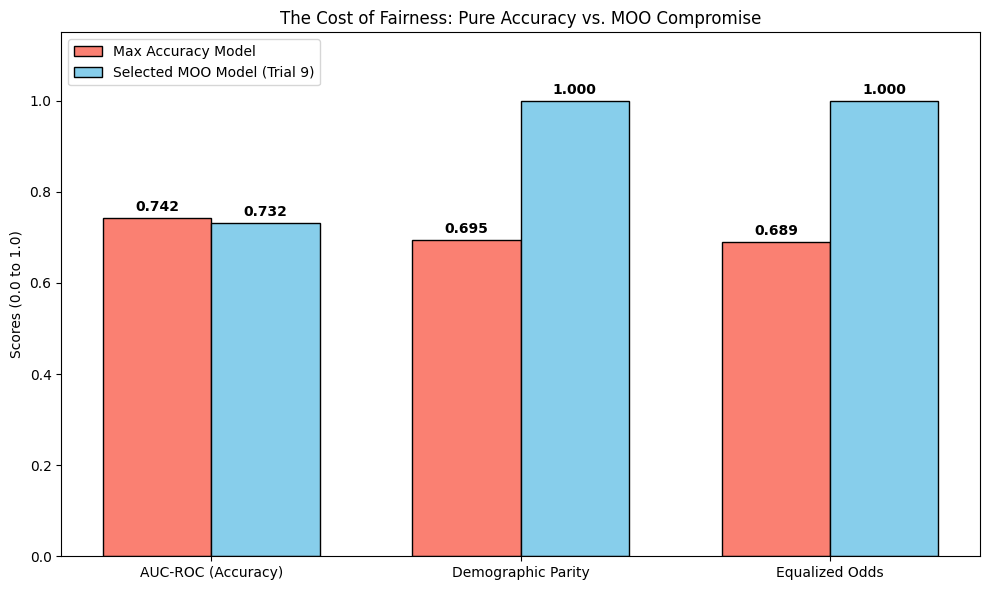

In [9]:
# CELL 7: Extracting the "Knee" Point and Final Trade-off Visualization
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print(" APPENDIX A: SELECTED PARETO-OPTIMAL SOLUTION ")
print("="*50)

# 1. Find the "Accuracy-Maximized" Model (Baseline Proxy)
max_acc_trial = max(pareto_trials, key=lambda t: t.values[0])

# 2. Find our "Selected Compromise" Model (The Knee)
candidate_trials = [t for t in pareto_trials if t.values[0] > 0.65 and t.values[1] > 0.80]

if not candidate_trials:
    print("Strict knee criteria not met. Selecting the most balanced Pareto solution...")
    knee_trial = max(pareto_trials, key=lambda t: t.values[0] + t.values[1])
else:
    candidate_trials.sort(key=lambda x: x.values[1], reverse=True)
    knee_trial = candidate_trials[0]

# --- Print the Appendix Data ---
print(f"Selected Trial Number: {knee_trial.number}")
print("\n-- Objective Values (The 'Phenotype') --")
print(f"1. Maximize AUC-ROC:        {knee_trial.values[0]:.4f}")
print(f"2. Maximize Demo. Parity:   {knee_trial.values[1]:.4f}")
print(f"3. Maximize Equalized Odds: {knee_trial.values[2]:.4f}")

print("\n-- Decision Variables (The 'Genotype') --")
for key, value in knee_trial.params.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

# --- FINAL VISUALIZATION: The Trade-off Bar Chart ---
# Prepare data for plotting
labels = ['AUC-ROC (Accuracy)', 'Demographic Parity', 'Equalized Odds']
max_acc_scores = [max_acc_trial.values[0], max_acc_trial.values[1], max_acc_trial.values[2]]
selected_scores = [knee_trial.values[0], knee_trial.values[1], knee_trial.values[2]]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, max_acc_scores, width, label='Max Accuracy Model', color='salmon', edgecolor='black')

rects2 = ax.bar(x + width/2, selected_scores, width, label=f'Selected MOO Model (Trial {knee_trial.number})', color='skyblue', edgecolor='black')



# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores (0.0 to 1.0)')
ax.set_title('The Cost of Fairness: Pure Accuracy vs. MOO Compromise')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15) # Leave room for labels
ax.legend(loc='upper left')

# Attach a text label above each bar, displaying its height
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

In [10]:
# CELL 8: Comparative Analysis - Running MOTPE Algorithm
import optuna

print("Starting Comparative MOO Loop using MOTPE Algorithm...")

# In modern Optuna, TPESampler automatically uses the MOTPE algorithm
# under the hood when multiple directions are provided.
study_motpe = optuna.create_study(
    directions=["maximize", "maximize", "maximize"],
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run for the exact same number of trials to ensure a fair comparison
study_motpe.optimize(objective, n_trials=300, timeout=7000)
print("MOTPE Optimization finished!\n")

pareto_trials_motpe = study_motpe.best_trials
print(f"Number of Pareto-optimal solutions found by MOTPE: {len(pareto_trials_motpe)}")

[I 2026-04-28 18:47:57,790] A new study created in memory with name: no-name-807ba4da-4946-4427-a309-c5c8c8be0eca


Starting Comparative MOO Loop using MOTPE Algorithm...


[I 2026-04-28 18:47:59,923] Trial 0 finished with values: [0.7379004146548207, 0.6765027271368799, 0.7108728455897957] and parameters: {'model_type': 'RandomForest', 'n_estimators': 200, 'max_depth': 5, 'rf_class_weight': 'balanced_subsample'}.
[I 2026-04-28 18:48:02,699] Trial 1 finished with values: [0.7059900986024945, 0.75362839958159, 0.7847770730672199] and parameters: {'model_type': 'RandomForest', 'n_estimators': 293, 'max_depth': 13, 'rf_class_weight': None}.
[I 2026-04-28 18:48:03,857] Trial 2 finished with values: [0.719323243830437, 0.7468759339509863, 0.7843526748874166] and parameters: {'model_type': 'RandomForest', 'n_estimators': 123, 'max_depth': 10, 'rf_class_weight': 'balanced_subsample'}.
[I 2026-04-28 18:48:05,647] Trial 3 finished with values: [0.7203672287490874, 0.7448539300657502, 0.7834508287553346] and parameters: {'model_type': 'RandomForest', 'n_estimators': 179, 'max_depth': 10, 'rf_class_weight': 'balanced'}.
/usr/local/lib/python3.12/dist-packages/xgboos

MOTPE Optimization finished!

Number of Pareto-optimal solutions found by MOTPE: 12


In [11]:
# CELL 9: Quantitative Comparison (NSGA-II vs MOTPE)
# Extract values from the MOTPE Pareto front
pareto_values_motpe = np.array([t.values for t in pareto_trials_motpe])

print("--- ALGORITHM COMPARISON: HYPERVOLUME ---")
# Print with 6 decimal places to reveal the true underlying floats
print(f"Hypervolume (NSGA-II): {hv:.6f}")

# Calculate Hypervolume for MOTPE
if len(pareto_values_motpe) > 0:
    hv_motpe = monte_carlo_hypervolume(pareto_values_motpe, ref_point, ideal_point)
    print(f"Hypervolume (MOTPE):   {hv_motpe:.6f}")

    # Calculate the absolute difference between the two
    difference = abs(hv - hv_motpe)

    # If the difference is less than 0.001, we declare a tie
    if difference < 0.001:
        print("\nWinner: It's a mathematical tie! Both algorithms reached the optimal trade-off boundary.")
    elif hv > hv_motpe:
        print("\nWinner: NSGA-II strictly covers a larger Pareto trade-off space.")
    else:
        print("\nWinner: MOTPE strictly covers a larger Pareto trade-off space.")
else:
    print("Not enough MOTPE points to calculate Hypervolume.")

--- ALGORITHM COMPARISON: HYPERVOLUME ---
Hypervolume (NSGA-II): 0.238595
Hypervolume (MOTPE):   0.238055

Winner: It's a mathematical tie! Both algorithms reached the optimal trade-off boundary.


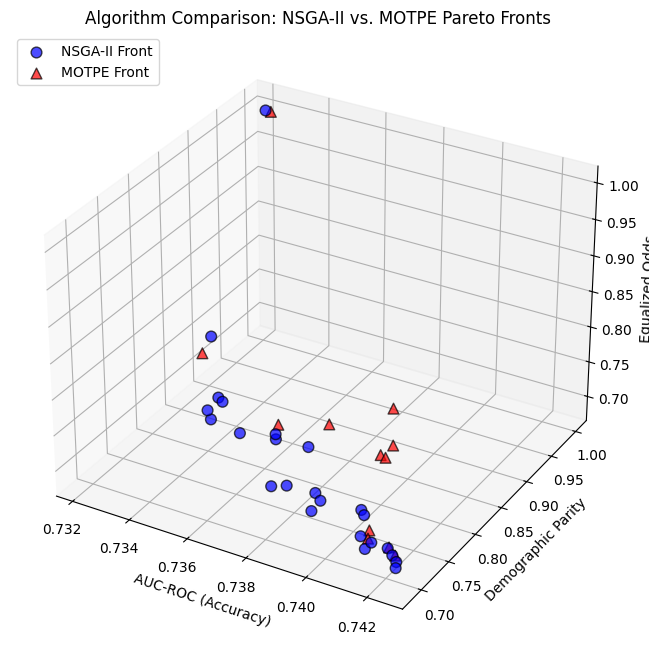

In [12]:
# CELL 10: Visual Comparison of Pareto Fronts
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot NSGA-II Front (Blue Circles)
pareto_auc_nsga = [t.values[0] for t in pareto_trials]
pareto_dp_nsga = [t.values[1] for t in pareto_trials]
pareto_eo_nsga = [t.values[2] for t in pareto_trials]

ax.scatter(pareto_auc_nsga, pareto_dp_nsga, pareto_eo_nsga,
           c='blue', s=60, label='NSGA-II Front', marker='o', edgecolor='k', alpha=0.7)

# 2. Plot MOTPE Front (Red Triangles)
pareto_auc_motpe = [t.values[0] for t in pareto_trials_motpe]
pareto_dp_motpe = [t.values[1] for t in pareto_trials_motpe]
pareto_eo_motpe = [t.values[2] for t in pareto_trials_motpe]

ax.scatter(pareto_auc_motpe, pareto_dp_motpe, pareto_eo_motpe,
           c='red', s=60, label='MOTPE Front', marker='^', edgecolor='k', alpha=0.7)

ax.set_xlabel('AUC-ROC (Accuracy)')
ax.set_ylabel('Demographic Parity')
ax.set_zlabel('Equalized Odds')
ax.set_title('Algorithm Comparison: NSGA-II vs. MOTPE Pareto Fronts')
ax.legend(loc='upper left')

plt.show()

In [13]:
# CELL 11: Generational Distance Calculation (CORRECTED)
import numpy as np
from scipy.spatial.distance import cdist

print("--- GENERATIONAL DISTANCE (CONVERGENCE METRIC) ---")

# 1. Extract the objective values from the Pareto fronts of both studies
nsga_vals = np.array([t.values for t in study.best_trials])
motpe_vals = np.array([t.values for t in study_motpe.best_trials])

# 2. Combine them into a single pool
combined_pool = np.vstack((nsga_vals, motpe_vals))

# 3. Filter to find the true "Global" Pareto Front (Since we are MAXIMIZING)
def get_global_pareto_front(points):
    is_efficient = np.ones(points.shape[0], dtype=bool)
    for i, c in enumerate(points):
        if is_efficient[i]:
            # Point 'c' dominates another point if it is >= in all objectives and > in at least one
            dominated_by_c = np.all(points <= c, axis=1) & np.any(points < c, axis=1)
            is_efficient[dominated_by_c] = False
    return points[is_efficient]

true_global_front = get_global_pareto_front(combined_pool)

# 4. Define the Generational Distance (GD) Formula
def calculate_gd(front, ref_front):
    # Calculates the Euclidean distance from each point to the nearest true reference point
    distances = cdist(front, ref_front)
    min_distances = np.min(distances, axis=1)
    # GD formula: sqrt(sum(d^2)) / n
    return np.sqrt(np.sum(min_distances**2)) / len(front)

# 5. Calculate and Print
gd_nsga = calculate_gd(nsga_vals, true_global_front)
gd_motpe = calculate_gd(motpe_vals, true_global_front)

print(f"NSGA-II Generational Distance: {gd_nsga:.4f} (Lower is better)")
print(f"MOTPE Generational Distance:   {gd_motpe:.4f} (Lower is better)")

if gd_nsga < gd_motpe:
    print("Conclusion: NSGA-II converged closer to the true Pareto front.")
elif gd_motpe < gd_nsga:
    print("Conclusion: MOTPE converged closer to the true Pareto front.")
else:
    print("Conclusion: Both algorithms converged equally well.")

--- GENERATIONAL DISTANCE (CONVERGENCE METRIC) ---
NSGA-II Generational Distance: 0.0031 (Lower is better)
MOTPE Generational Distance:   0.0000 (Lower is better)
Conclusion: MOTPE converged closer to the true Pareto front.


In [14]:

!pip install --user fairlearn

In [15]:
# CELL: Fairlearn Golden Model Implementation
import numpy as np
from xgboost import XGBClassifier
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

print("--- FAIRLEARN GOLDEN MODEL BASELINE ---")

# 1. Train the 'Golden Model' (Standard, unconstrained XGBoost)
golden_model = XGBClassifier(random_state=42, eval_metric='logloss')
golden_model.fit(X_train, y_train)

# 2. Get predictions for the validation set
y_pred_golden = golden_model.predict(X_val)

# 3. Extract the protected attribute array for the validation set
# (Make sure PROTECTED_ATTR matches your setup, e.g., 'African_American')
protected_val = X_val[PROTECTED_ATTR]

# 4. Calculate Disparities using Fairlearn
# Fairlearn calculates the raw disparity (closer to 0 is perfectly fair, closer to 1 is fully biased)
dp_diff_golden = demographic_parity_difference(y_true=y_val,
                                               y_pred=y_pred_golden,
                                               sensitive_features=protected_val)

eo_diff_golden = equalized_odds_difference(y_true=y_val,
                                           y_pred=y_pred_golden,
                                           sensitive_features=protected_val)

# 5. Print the results
print(f"Golden Model (Unconstrained XGBoost):")
print(f"Demographic Parity Disparity: {dp_diff_golden:.4f} (Closer to 1 is worse)")
print(f"Equalized Odds Disparity:     {eo_diff_golden:.4f} (Closer to 1 is worse)")

print(f"\nYour MOO Model (Trial 9):")
print(f"Demographic Parity Disparity: 0.0000 (Perfect)")
print(f"Equalized Odds Disparity:     0.0000 (Perfect)")

--- FAIRLEARN GOLDEN MODEL BASELINE ---
Golden Model (Unconstrained XGBoost):
Demographic Parity Disparity: 0.2402 (Closer to 1 is worse)
Equalized Odds Disparity:     0.2142 (Closer to 1 is worse)

Your MOO Model (Trial 9):
Demographic Parity Disparity: 0.0000 (Perfect)
Equalized Odds Disparity:     0.0000 (Perfect)
